# CDGS production

These examples are related to the production of a Common Decay Gamma Source (CDGS) file starting from a cloud point (often coming from a flunet calculation)

## The interpolation

The starting point to create CDGS is often a cloud point (representing the centroids of a mesh)
that have information on the specific atomic density of each radio-isotope of interest and volume
in each cell. This information needs to be translated into a structured mesh.

To do so, there are two main thing to decide:
- the bin sizes
- how to interpolate the cloud point on the new mesh

These two main points are controlled respectively by the
``InterpolationKernel`` and ``MeshDefinition`` object families

### MeshDefinition

There are three concrete `MeshDefinition` children, each controlling how the structured grid is built from the cloud point:

| Class | What you provide | How the voxel size is determined |
|---|---|---|
| `MeshByAverageDistance` | `factor` (float) | Average nearest-neighbour distance × factor |
| `MeshByBinSize` | `bin_size` (x, y, z tuple) | Fixed bin size you specify directly |
| `MeshByNumberOfVoxels` | `n_voxels` (nx, ny, nz tuple) + bounding box | bbox extent / n_voxels per axis |

All three accept an optional `bbox` dict (`x_min`, `x_max`, `y_min`, `y_max`, `z_min`, `z_max`) to override the automatic bounding box.

The following shows an example of these definition can change significantly the mesh that will be produced
inside the ``CDGS`` object

In [ ]:
import pandas as pd
import pyvista as pv
from f4enix.output.cdgs import MeshByAverageDistance, MeshByBinSize, MeshByNumberOfVoxels

# Read the same cloud point used in the rest of the notebook
source_activity = pd.read_csv('activity_example1.csv')
source_activity.columns = source_activity.columns.str.strip()
coords = source_activity[['x', 'y', 'z']].values

bbox = {
    "x_min": coords[:, 0].min(),
    "x_max": coords[:, 0].max(),
    "y_min": coords[:, 1].min(),
    "y_max": coords[:, 1].max(),
    "z_min": coords[:, 2].min(),
    "z_max": coords[:, 2].max(),
}

definitions = {
    "MeshByAverageDistance(factor=10)": (MeshByAverageDistance(factor=10)),
    "MeshByBinSize(bin_size=(50, 60, 50))": (MeshByBinSize(bin_size=(50, 60, 50))),
    "MeshByNumberOfVoxels(n_voxels=(10,5,10))": (MeshByNumberOfVoxels(n_voxels=(10, 5, 10), bbox=bbox)),
}

for mesh_name, mesh_def in definitions.items():
    print(f"\nBuilding mesh: {mesh_name}")
    mesh = mesh_def._build_grid(coords)
    print(mesh)



Building mesh: MeshByAverageDistance(factor=10)
StructuredGrid (0x23415ccb820)
  N Cells:      484
  N Points:     1058
  X Bounds:     -7.447e-02, 7.447e-02
  Y Bounds:     -2.626e-01, -2.508e-01
  Z Bounds:     7.896e-01, 9.384e-01
  Dimensions:   23, 2, 23
  N Arrays:     0

Building mesh: MeshByBinSize(bin_size=(50, 60, 50))
StructuredGrid (0x23415ccb520)
  N Cells:      1
  N Points:     8
  X Bounds:     -2.507e+01, 2.507e+01
  Y Bounds:     -3.026e+01, 2.975e+01
  Z Bounds:     -2.421e+01, 2.594e+01
  Dimensions:   2, 2, 2
  N Arrays:     0

Building mesh: MeshByNumberOfVoxels(n_voxels=(10,5,10))
StructuredGrid (0x23415cca8c0)
  N Cells:      500
  N Points:     726
  X Bounds:     -7.111e-02, 7.111e-02
  Y Bounds:     -2.592e-01, -2.541e-01
  Z Bounds:     7.930e-01, 9.350e-01
  Dimensions:   11, 6, 11
  N Arrays:     0


### InterpolationKernel

There are two concrete `InterpolationKernel` children. Both share the same **neighbour search** strategy (a sphere around each source point) but differ in **how activity is distributed** to the neighbours:

| Class | Key parameter(s) | Neighbour search | Activity distribution |
|---|---|---|---|
| `SphereKernel` | `radius` **or** `n_voxels` | sphere of fixed `radius`, or `n_voxels × voxel_size` | uniform — each neighbour receives an equal share |
| `DistanceKernel` | `radius` **or** `n_voxels` | same as `SphereKernel` | inverse-distance weighted — closer neighbours receive proportionally more |

It is important to notice that both these methods will always conserve locally (how local depends on the interpolation sphere dimension) and globally the total activity.

`n_voxels` is the more practical option: the search radius is set automatically as a multiple of the mesh voxel size, so it adapts when you change the `MeshDefinition`.

The following example show the effect of using different radius searches on the final interpolated results.

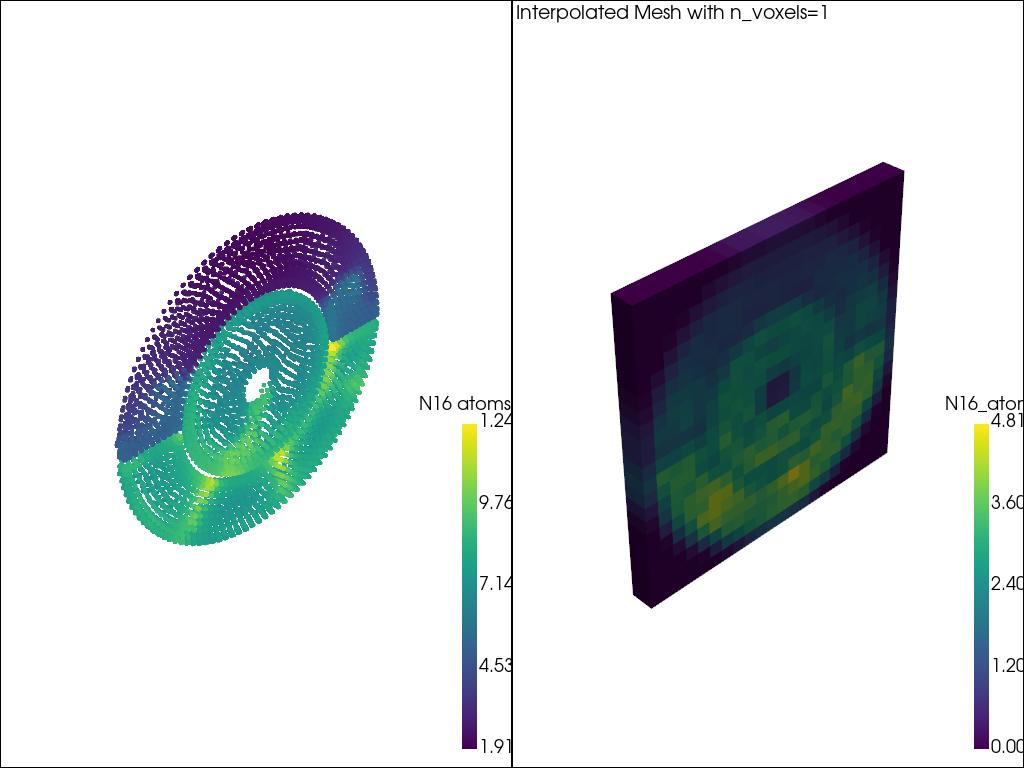

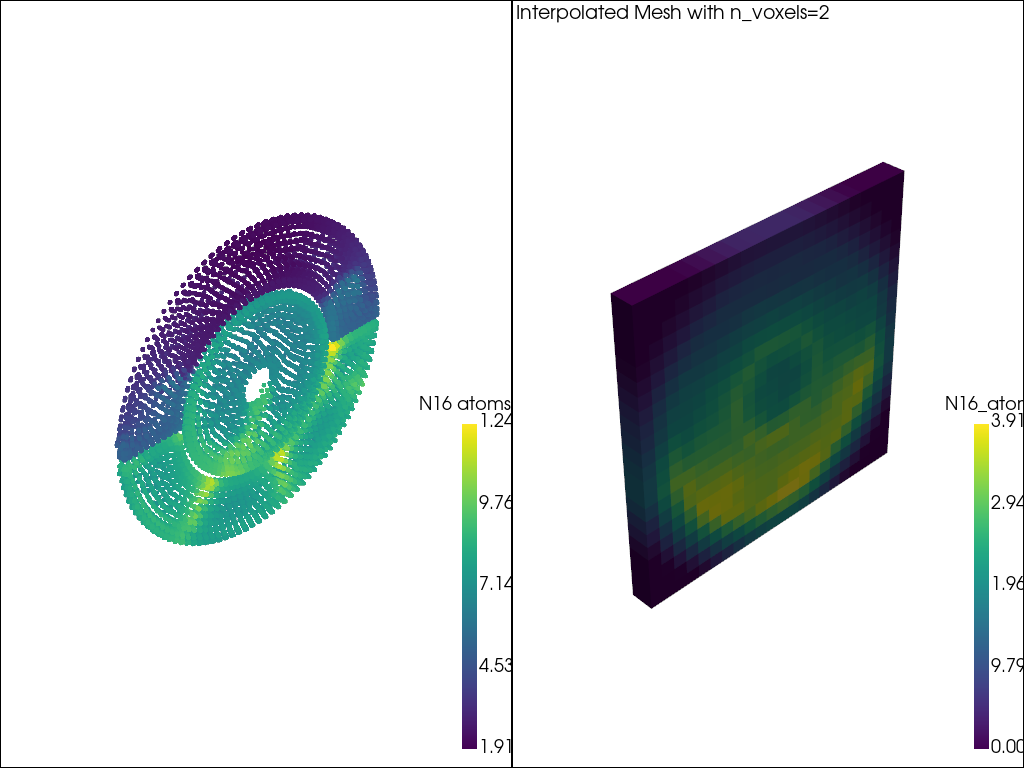

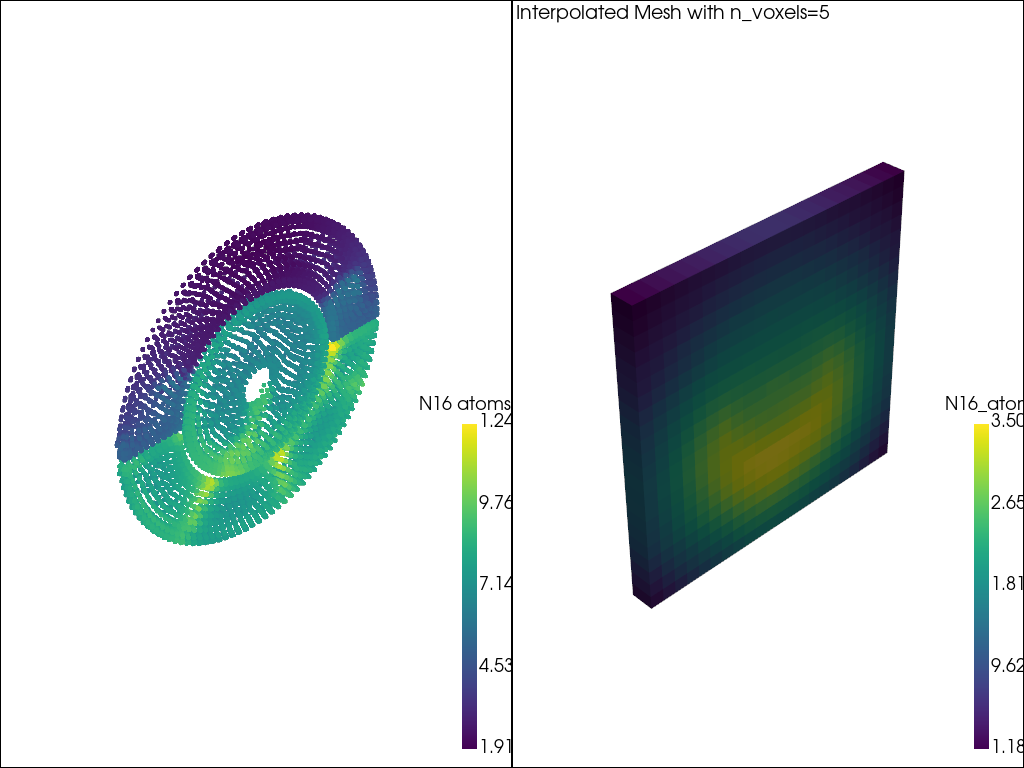

In [16]:
import pandas as pd
import pyvista as pv
from f4enix.output.cdgs import CDGS, SphereKernel, MeshByAverageDistance

source_activity = pd.read_csv('activity_example1.csv')
source_activity.columns = source_activity.columns.str.strip()  # Strip whitespace from column names
cloudpoint = pv.PolyData(source_activity[['x', 'y', 'z']].values)
cloudpoint['N16 atoms/m3'] = source_activity['n16'].values

for n_voxel in [1, 2, 5]:
    cdgs = CDGS.from_cloud_point(
        'activity_example1.csv',
        {"N16": "n16"},
        interpolation_kernel=SphereKernel(n_voxels=n_voxel),
        mesh_definition=MeshByAverageDistance(factor=10),
        col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"}
        )

    interpolated_mesh = cdgs.mesh

    # plotting
    plotter = pv.Plotter(shape=(1, 2))

    plotter.subplot(0, 0)
    plotter.add_mesh(
        cloudpoint,
        scalars='N16 atoms/m3',
        scalar_bar_args={"vertical": True},
    )


    plotter.subplot(0, 1)
    plotter.add_mesh(
        cdgs.mesh,
        scalars='N16_atoms',
        scalar_bar_args={"vertical": True},
    )
    plotter.add_text(f"Interpolated Mesh with n_voxels={n_voxel}", font_size=12)

    plotter.show(jupyter_backend="static")


## The CDGS object

As seen above, the creation of a regular mesh and interpolation happens directly inside the
``CDGS`` object. The data is stored in a pyvista grid and can be further manipulated if needed. In addition to the interpolated atomic density, also the activity is computed and stored in the mesh.

Helper methods are provided to dump the data either in .vtk or .cdgs (ASCII) format.

In [ ]:
import actigamma as ag

db = ag.Decay2012Database()

# get halflife of Co60
print(db.gethalflife("Co60"))

# get gamma lines of Co60
print(db.getenergies("Co60", spectype="gamma"))

166337000.0
[ 347140.  826100. 1173230. 1332490. 2158570. 2505690.]


In [ ]:
inv = ag.UnstablesInventory(data=[
    (db.getzai("Co60"), ag.activity_from_atoms(db, "Co60", 2.36853908671135e+22)),
    (db.getzai("Pu238"), ag.activity_from_atoms(db, "Pu238", 15970864933847.367)),
    (db.getzai("U235"), ag.activity_from_atoms(db, "U235", 1.730297451446211e+25))
])

In [ ]:
for zai, activity in inv:
    name = db.getname(zai)
    print(f"{name}: {activity:.3e} Bq")
    energies = db.getenergies(name, spectype='gamma')
    intensities = db.getintensities(name, spectype='gamma')*activity
    print(f"Gamma lines for {name}:")
    for energy, intensity in zip(energies, intensities):
        print(f"  Energy: {energy:.2f} keV, Intensity: {intensity:.3e} Bq")

Co60: 9.870e+13 Bq
Gamma lines for Co60:
  Energy: 347140.00 keV, Intensity: 7.402e+09 Bq
  Energy: 826100.00 keV, Intensity: 7.501e+09 Bq
  Energy: 1173230.00 keV, Intensity: 9.855e+13 Bq
  Energy: 1332490.00 keV, Intensity: 9.868e+13 Bq
  Energy: 2158570.00 keV, Intensity: 1.184e+09 Bq
  Energy: 2505690.00 keV, Intensity: 1.974e+06 Bq
Pu238: 4.000e+03 Bq
Gamma lines for Pu238:
  Energy: 34300.00 keV, Intensity: 2.440e-09 Bq
  Energy: 43498.00 keV, Intensity: 1.580e+00 Bq
  Energy: 62800.00 keV, Intensity: 9.600e-07 Bq
  Energy: 99853.00 keV, Intensity: 2.940e-01 Bq
  Energy: 140500.00 keV, Intensity: 2.680e-07 Bq
  Energy: 152720.00 keV, Intensity: 3.748e-02 Bq
  Energy: 174600.00 keV, Intensity: 2.080e-07 Bq
  Energy: 192800.00 keV, Intensity: 6.400e-08 Bq
  Energy: 200980.00 keV, Intensity: 1.632e-04 Bq
  Energy: 203200.00 keV, Intensity: 3.480e-07 Bq
  Energy: 234600.00 keV, Intensity: 4.800e-08 Bq
  Energy: 236400.00 keV, Intensity: 1.280e-06 Bq
  Energy: 258200.00 keV, Intensity